# 01 · EDA — MovieLens-1M as an implicit-feedback problem

We treat MovieLens-1M as a **recommendation** problem, not a rating-prediction
one: a rating >= 4 is a positive *implicit* interaction (the user liked it) and
everything else is treated as no-signal. This matches what production
recommenders actually observe — clicks and plays, not star ratings.

The key methodological choice is the **temporal split**: we hold out each
user's most recent interactions for testing. A random split would let the model
peek at a user's future and inflate every offline metric.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)

In [2]:
from src.data.load import load_ratings, temporal_split, LIKE_THRESHOLD
df = load_ratings()
print(f"interactions : {len(df):,}")
print(f"users        : {df.user_idx.nunique():,}")
print(f"items        : {df.item_idx.nunique():,}")
print(f"like rate (>= {LIKE_THRESHOLD} stars): {df.liked.mean():.2%}")
df.head()

interactions : 1,000,209
users        : 6,040
items        : 3,706
like rate (>= 4 stars): 57.52%


,user,item,rating,timestamp,liked,user_idx,item_idx
0,1,1193,5,978300760,1,0,1104
1,1,661,3,978302109,0,0,639
2,1,914,3,978301968,0,0,853
3,1,3408,4,978300275,1,0,3177
4,1,2355,5,978824291,1,0,2162


## Rating distribution and sparsity

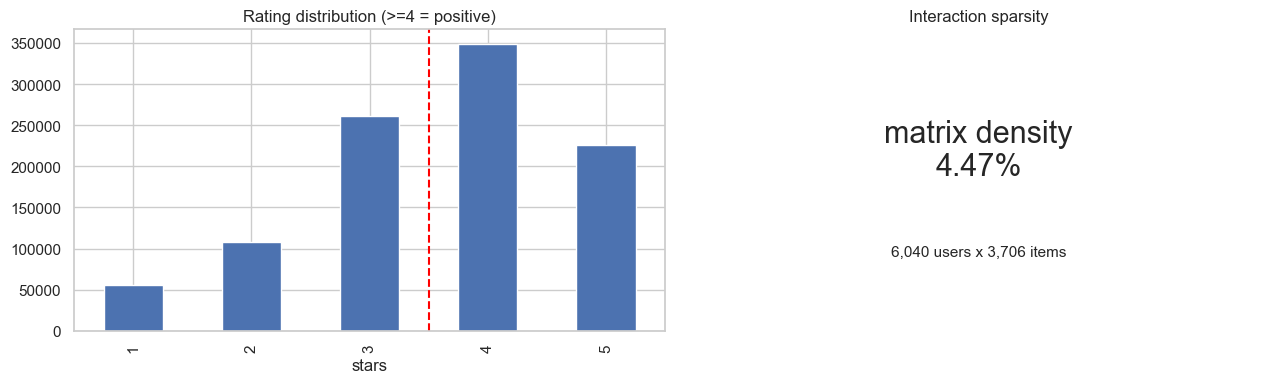

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.rating.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].axvline(LIKE_THRESHOLD - 1.5, color="red", ls="--"); axes[0].set_title("Rating distribution (>=4 = positive)")
axes[0].set_xlabel("stars")
density = len(df) / (df.user_idx.nunique() * df.item_idx.nunique())
axes[1].text(0.5, 0.6, f"matrix density\n{density:.2%}", ha="center", va="center", fontsize=22)
axes[1].text(0.5, 0.25, f"{df.user_idx.nunique():,} users x {df.item_idx.nunique():,} items", ha="center", fontsize=11)
axes[1].axis("off"); axes[1].set_title("Interaction sparsity")
plt.tight_layout(); plt.savefig(FIG / "01_ratings_sparsity.png", dpi=120, bbox_inches="tight"); plt.show()

## The long tail of item popularity
A few blockbusters dominate — this is exactly why a popularity baseline is hard to beat, and why *coverage* matters as a metric.

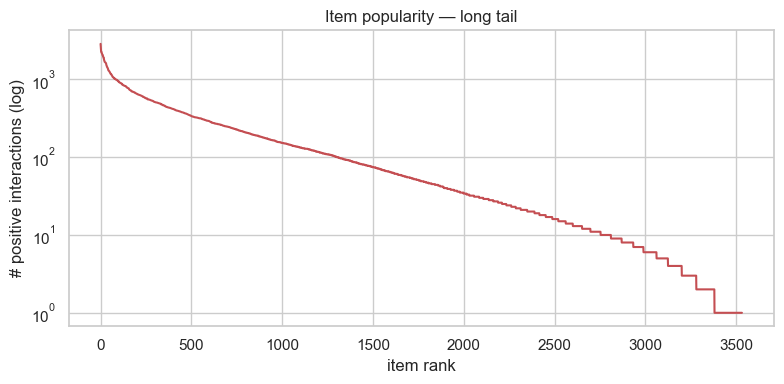

top-20 items account for 7.4% of all positive interactions


In [4]:
item_pop = df[df.liked == 1].item_idx.value_counts().values
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(len(item_pop)), np.sort(item_pop)[::-1], color="#c44e52")
ax.set_yscale("log"); ax.set_xlabel("item rank"); ax.set_ylabel("# positive interactions (log)")
ax.set_title("Item popularity — long tail")
plt.tight_layout(); plt.savefig(FIG / "01_long_tail.png", dpi=120, bbox_inches="tight"); plt.show()
top20_share = np.sort(item_pop)[::-1][:20].sum() / item_pop.sum()
print(f"top-20 items account for {top20_share:.1%} of all positive interactions")

## Temporal split

In [5]:
sp = temporal_split(df, test_frac=0.2, min_interactions=10)
print(f"train interactions : {len(sp.train):,}")
print(f"test interactions  : {len(sp.test):,}")
print(f"users kept (>=10)  : {sp.train.user_idx.nunique():,}")
# confirm no leakage: every test timestamp is >= that user's max train timestamp
merged = sp.test.groupby("user_idx").timestamp.min().rename("test_min").to_frame().join(
    sp.train.groupby("user_idx").timestamp.max().rename("train_max"))
leak = (merged.test_min < merged.train_max).mean()
print(f"users with any train-after-test leakage: {leak:.2%}  (should be 0)")

train interactions : 797,758
test interactions  : 202,451
users kept (>=10)  : 6,040
users with any train-after-test leakage: 0.00%  (should be 0)


## Takeaways

- Highly sparse (~4.5% dense) implicit-feedback matrix with a heavy popularity
  tail — the setting real recommenders face.
- The temporal split is verified leakage-free: no user's test interactions
  predate their training interactions.
- Because a handful of items carry most of the signal, **coverage** is reported
  alongside accuracy in notebook 02 — an accurate model that only ever
  recommends blockbusters is not a useful one.